In [10]:
from __future__ import annotations

import os
import torch

import numpy as np

import h5py 


from collections import OrderedDict

from dataclasses import dataclass
from typing import Optional, Tuple, Union

from pathlib import Path

from torch.utils.data import Dataset, DataLoader, get_worker_info

In [2]:

@dataclass(frozen=True)
class PatchSpec:
    patch_size: Shape3              # (Dz, Dy, Dx)
    samples_per_volume: int = 1     # how many samples to draw per "volume index"
    seed: int = 0                   # base seed for deterministic patch coords



class HDF5PatchDataset(Dataset):
    """
    Loads 3D patches from an HDF5 dataset.

    Supports two common layouts:

    A) dataset shape = (N, Z, Y, X)          -> N independent volumes
    B) dataset shape = (Z, Y, X)             -> single large volume (treat as N=1)

    Returns:
        patch: torch.Tensor of shape (1, Dz, Dy, Dx) (channel-first)
        (optional) meta: dict with volume_idx and origin indices
    """

    def __init__(
        self,
        hdf5_file_path: str,
        key: str = "data",
        patch: PatchSpec = PatchSpec(patch_size=(64, 64, 64), samples_per_volume=16, seed=0),
        return_meta: bool = False,
        dtype: torch.dtype = torch.float32,
        transform=None,  # optional callable(patch_tensor)->patch_tensor
    ):
        self.hdf5_file_path = hdf5_file_path
        self.key = key
        self.patch = patch
        self.return_meta = return_meta
        self.dtype = dtype
        self.transform = transform

        self._h5: Optional[h5py.File] = None
        self._ds = None

        # Read shape once (no persistent handle kept here)
        with h5py.File(self.hdf5_file_path, "r") as f:
            ds = f[self.key]
            self._ds_shape = tuple(ds.shape)
            self._ds_ndim = ds.ndim

        if self._ds_ndim == 4:
            self._n_vols = self._ds_shape[0]
            self._vol_shape = self._ds_shape[1:]  # (Z,Y,X)
        elif self._ds_ndim == 3:
            self._n_vols = 1
            self._vol_shape = self._ds_shape       # (Z,Y,X)
        else:
            raise ValueError(f"Expected dataset ndim 3 or 4, got {self._ds_ndim} with shape {self._ds_shape}")

        Dz, Dy, Dx = self.patch.patch_size
        Z, Y, X = self._vol_shape
        if Dz > Z or Dy > Y or Dx > X:
            raise ValueError(f"patch_size {self.patch.patch_size} must fit into volume shape {self._vol_shape}")

        self._length = self._n_vols * self.patch.samples_per_volume

    def __len__(self) -> int:
        return self._length

    def _ensure_open(self):
        """Open HDF5 per worker/process (safe with num_workers>0)."""
        if self._h5 is not None:
            return

        # Each worker must have its own file handle
        self._h5 = h5py.File(self.hdf5_file_path, "r", libver="latest", swmr=True)
        self._ds = self._h5[self.key]

    def _rng_for_index(self, idx: int) -> np.random.Generator:
        """
        Deterministic RNG per (worker, idx) so shuffling is stable and
        different workers don't sample identical patches.
        """
        wi = get_worker_info()
        worker_id = wi.id if wi is not None else 0
        # Mix seed, worker_id, and idx into a uint64 seed
        seed = np.uint64(self.patch.seed) ^ (np.uint64(worker_id) << 32) ^ np.uint64(idx)
        return np.random.default_rng(seed)

    def _sample_origin(self, rng: np.random.Generator) -> Index3:
        Z, Y, X = self._vol_shape
        Dz, Dy, Dx = self.patch.patch_size
        z0 = int(rng.integers(0, Z - Dz + 1))
        y0 = int(rng.integers(0, Y - Dy + 1))
        x0 = int(rng.integers(0, X - Dx + 1))
        return (z0, y0, x0)

    def __getitem__(self, idx: int):
        self._ensure_open()

        vol_idx = idx // self.patch.samples_per_volume
        rng = self._rng_for_index(idx)
        z0, y0, x0 = self._sample_origin(rng)
        Dz, Dy, Dx = self.patch.patch_size

        if self._ds_ndim == 4:
            arr = self._ds[vol_idx, z0:z0+Dz, y0:y0+Dy, x0:x0+Dx]
        else:  # 3D single volume
            arr = self._ds[z0:z0+Dz, y0:y0+Dy, x0:x0+Dx]

        # h5py returns numpy-like array; convert
        patch = torch.from_numpy(np.asarray(arr))
        # add channel dim: (1, Dz, Dy, Dx)
        if patch.ndim == 3:
            patch = patch.unsqueeze(0)

        patch = patch.to(self.dtype)

        if self.transform is not None:
            patch = self.transform(patch)

        if self.return_meta:
            meta = {
                "volume_idx": int(vol_idx),
                "origin_zyx": (int(z0), int(y0), int(x0)),
                "patch_size": tuple(self.patch.patch_size),
            }
            return patch, meta

        return patch

In [8]:
file_path = Path("/Volumes/CT-Data/CT_Hys/EPP_2020-12-09.h5")

In [31]:
ds = HDF5PatchDataset(
    file_path,
    key="volume",
    patch=PatchSpec(patch_size=(64, 64, 64), samples_per_volume=32, seed=123),
    return_meta=True,
)

loader = DataLoader(
    ds,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

for x, meta in loader:
    print(x.shape, meta["origin_zyx"][0])
    break

torch.Size([4, 1, 64, 64, 64]) tensor([1237, 1137,  623, 1243])


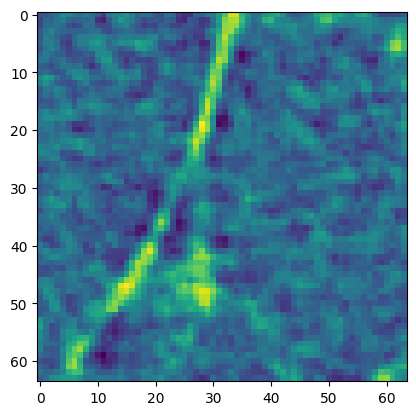

In [38]:
import matplotlib.pyplot as plt


plt.imshow(x[0,0,0,::])

In [3]:
Shape3 = Tuple[int, int, int]


def _count_1d(L: int, P: int, S: int) -> int:
    """Full patches only: starts 0..(L-P) step S."""
    if L < P:
        return 0
    return (L - P) // S + 1


class _LRU:
    """Tiny LRU cache for numpy arrays (e.g., volumes)."""
    def __init__(self, max_items: int):
        self.max_items = int(max_items)
        self._d = OrderedDict()

    def get(self, key):
        if key not in self._d:
            return None
        self._d.move_to_end(key)
        return self._d[key]

    def put(self, key, val):
        self._d[key] = val
        self._d.move_to_end(key)
        while len(self._d) > self.max_items:
            self._d.popitem(last=False)


class MultiH5GridPatches(Dataset):
    """
    Deterministic 3D patches on a stride grid from multiple HDF5 files.

    Expected dataset layout per file:
      - (Z, Y, X)   OR
      - (N, Z, Y, X)  (multiple volumes in one file)

    RAM caching:
      cache_volumes=0 -> no caching
      cache_volumes=k -> keep up to k full volumes (numpy arrays) in memory (LRU)
        (useful if I/O is slow and volumes fit in RAM)
    """

    def __init__(
        self,
        h5_paths: Union[str, List[str]],
        key: str = "data",
        patch_size: Shape3 = (64, 64, 64),
        stride: Shape3 = (32, 32, 32),
        cache_volumes: int = 0,
        dtype: torch.dtype = torch.float32,
    ):
        self.paths = [h5_paths] if isinstance(h5_paths, str) else list(h5_paths)
        self.key = key
        self.patch_size = tuple(map(int, patch_size))
        self.stride = tuple(map(int, stride))
        self.dtype = dtype

        self.cache = _LRU(cache_volumes) if cache_volumes and cache_volumes > 0 else None

        # Build a simple index: global_idx -> (file_i, vol_i, iz, iy, ix)
        self._items = []  # list of tuples
        self._shapes = [] # per (file_i, vol_i): (Z,Y,X)

        Dz, Dy, Dx = self.patch_size
        Sz, Sy, Sx = self.stride

        for fi, p in enumerate(self.paths):
            with h5py.File(p, "r") as f:
                ds = f[key]
                shape = ds.shape

                if ds.ndim == 3:
                    nvol = 1
                    vol_shape = shape
                    self._shapes.append((fi, 0, vol_shape))
                    Z, Y, X = vol_shape
                    nz, ny, nx = _count_1d(Z, Dz, Sz), _count_1d(Y, Dy, Sy), _count_1d(X, Dx, Sx)
                    for iz in range(nz):
                        for iy in range(ny):
                            for ix in range(nx):
                                self._items.append((fi, 0, iz, iy, ix))

                elif ds.ndim == 4:
                    nvol = shape[0]
                    for vi in range(nvol):
                        vol_shape = shape[1:]
                        self._shapes.append((fi, vi, vol_shape))
                        Z, Y, X = vol_shape
                        nz, ny, nx = _count_1d(Z, Dz, Sz), _count_1d(Y, Dy, Sy), _count_1d(X, Dx, Sx)
                        for iz in range(nz):
                            for iy in range(ny):
                                for ix in range(nx):
                                    self._items.append((fi, vi, iz, iy, ix))
                else:
                    raise ValueError(f"{p}: dataset ndim must be 3 or 4, got {ds.ndim} with shape {shape}")

        if len(self._items) == 0:
            raise ValueError("No patches found (check patch_size/stride vs volume sizes).")

    def __len__(self) -> int:
        return len(self._items)

    def dataset_info(self) -> dict:
        # approximate "if materialized" size in GB
        Dz, Dy, Dx = self.patch_size
        nvox = Dz * Dy * Dx
        bytes_per = torch.tensor([], dtype=self.dtype).element_size() * nvox
        return {
            "n_files": len(self.paths),
            "key": self.key,
            "patch_size_zyx": self.patch_size,
            "stride_zyx": self.stride,
            "total_patches": len(self),
            "approx_materialized_gb": (len(self) * bytes_per) / (1024**3),
            "cache_volumes": 0 if self.cache is None else self.cache.max_items,
        }

    def _load_volume_np(self, file_i: int, vol_i: int) -> np.ndarray:
        """
        Loads a full volume as numpy array (for caching).
        Keyed by (file_i, vol_i).
        """
        cache_key = (file_i, vol_i)
        if self.cache is not None:
            v = self.cache.get(cache_key)
            if v is not None:
                return v

        path = self.paths[file_i]
        with h5py.File(path, "r") as f:
            ds = f[self.key]
            if ds.ndim == 3:
                vol = np.asarray(ds[...])
            else:
                vol = np.asarray(ds[vol_i, ...])

        if self.cache is not None:
            self.cache.put(cache_key, vol)
        return vol

    def __getitem__(self, idx: int) -> torch.Tensor:
        fi, vi, iz, iy, ix = self._items[idx]

        Dz, Dy, Dx = self.patch_size
        Sz, Sy, Sx = self.stride

        z0, y0, x0 = iz * Sz, iy * Sy, ix * Sx

        # If caching is enabled: slice from cached numpy volume
        if self.cache is not None:
            vol = self._load_volume_np(fi, vi)
            patch_np = vol[z0:z0+Dz, y0:y0+Dy, x0:x0+Dx]
        else:
            # No cache: slice directly from file (low RAM, more I/O)
            path = self.paths[fi]
            with h5py.File(path, "r") as f:
                ds = f[self.key]
                if ds.ndim == 3:
                    patch_np = ds[z0:z0+Dz, y0:y0+Dy, x0:x0+Dx]
                else:
                    patch_np = ds[vi, z0:z0+Dz, y0:y0+Dy, x0:x0+Dx]

            patch_np = np.asarray(patch_np)

        x = torch.from_numpy(patch_np).unsqueeze(0).to(self.dtype)  # (1, Dz, Dy, Dx)
        return x

In [11]:
ds = MultiH5GridPatches(
    [file_path],
    key="volume",
    patch_size=(64, 64, 64),
    stride=(64, 64, 64),
    cache_volumes=1,          # keep 1 full volume in RAM (LRU)
    dtype=torch.float32
)

print(ds.dataset_info())
print("len =", len(ds))

# DataLoader note: if cache_volumes>0 with multiple workers, each worker has its own cache
from torch.utils.data import DataLoader
loader = DataLoader(ds, batch_size=4, shuffle=False, num_workers=2)
x = next(iter(loader))
print(x.shape)

{'n_files': 1, 'key': 'volume', 'patch_size_zyx': (64, 64, 64), 'stride_zyx': (64, 64, 64), 'total_patches': 41650, 'approx_materialized_gb': 40.673828125, 'cache_volumes': 1}
len = 41650


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/christian/.pyenv/versions/3.11.7/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/christian/.pyenv/versions/3.11.7/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'MultiH5GridPatches' on <module '__main__' (built-in)>


KeyboardInterrupt: 